In [ ]:
!pip install pandas numpy lightgbm xgboost scikit-learn pmdarima matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 27.5 MB/s eta 0:00:00


1. Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error

import lightgbm as lgb
from xgboost import XGBRegressor
from pmdarima import auto_arima

print("All libraries imported successfully.")

All libraries imported successfully.


We will load the train.csv, test.csv, features.csv, and stores.csv files into pandas DataFrames. These datasets contain sales, promotional information, store details, and additional features that will be used for forecasting.

2. Load data

In [ ]:
train_df = pd.read_csv('train.csv', parse_dates=['Date'])
test_df = pd.read_csv('test.csv', parse_dates=['Date'])
features_df = pd.read_csv('features.csv', parse_dates=['Date'])
stores_df = pd.read_csv('stores.csv')

3. MERGE DATASETS
To prepare the data for modeling, we need to combine the train_df, features_df, and stores_df into a single DataFrame. This will allow us to use store characteristics and promotional events as features for our sales forecasting model. We will perform left joins based on Store and Date.

In [ ]:
train_df = pd.merge(train_df, features_df, on=['Store', 'Date'], how='left')
train_df = pd.merge(train_df, stores_df, on=['Store'], how='left')

test_df = pd.merge(test_df, features_df, on=['Store', 'Date'], how='left')
test_df = pd.merge(test_df, stores_df, on=['Store'], how='left')

4. DATA PREPROCESSING AND FEATURE ENGINEERING
In this section, we will prepare the merged data for model training. This includes handling missing values, extracting time-based features from the 'Date' column, and creating other relevant features that could influence sales. We will also address categorical variables and prepare the data for splitting into training and validation sets.

In [ ]:
# Handle missing values in Markdown columns by filling with 0 (assuming no markdown means 0 promotion)
train_df = train_df.fillna(0)
test_df = test_df.fillna(0)

# Extract date-related features
for df in [train_df, test_df]:
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
    df['Day'] = df['Date'].dt.day
    df['DayOfWeek'] = df['Date'].dt.dayofweek
    df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)

# Convert 'IsHoliday' from boolean to integer (if not already converted during merge)
for df in [train_df, test_df]:
    if 'IsHoliday_x' in df.columns:
        df['IsHoliday'] = df['IsHoliday_x'].astype(int)
        df = df.drop(columns=['IsHoliday_x'])
    if 'IsHoliday_y' in df.columns:
        df = df.drop(columns=['IsHoliday_y'])

# One-hot encode 'Type' column from stores_df
train_df = pd.get_dummies(train_df, columns=['Type'], drop_first=True, prefix='StoreType')
test_df = pd.get_dummies(test_df, columns=['Type'], drop_first=True, prefix='StoreType')

print("Preprocessing and Feature Engineering Complete!")
print("Train DataFrame head after preprocessing:")
print(train_df.head())
print("Test DataFrame head after preprocessing:")
print(test_df.head())

Preprocessing and Feature Engineering Complete!
Train DataFrame head after preprocessing:
   Store  Dept       Date  Weekly_Sales  IsHoliday_x  Temperature  Fuel_Price  \
0      1     1 2010-02-05      24924.50        False        42.31       2.572   
1      1     1 2010-02-12      46039.49         True        38.51       2.548   
2      1     1 2010-02-19      41595.55        False        39.93       2.514   
3      1     1 2010-02-26      19403.54        False        46.63       2.561   
4      1     1 2010-03-05      21827.90        False        46.50       2.625   

   MarkDown1  MarkDown2  MarkDown3  ...    Size  Year  Month  Week  Day  \
0        0.0        0.0        0.0  ...  151315  2010      2     5    5   
1        0.0        0.0        0.0  ...  151315  2010      2     6   12   
2        0.0        0.0        0.0  ...  151315  2010      2     7   19   
3        0.0        0.0        0.0  ...  151315  2010      2     8   26   
4        0.0        0.0        0.0  ...  151315 

5. Data Splitting

We will split the preprocessed train_df into features (X) and target (y). For time series data, it's crucial to use a time-aware splitting strategy. We'll use TimeSeriesSplit to create a validation set that chronologically follows the training set.

In [ ]:
# Define features (X) and target (y)
features = [col for col in train_df.columns if col not in ['Date', 'Weekly_Sales', 'IsHoliday_x', 'IsHoliday_y']]
X = train_df[features]
y = train_df['Weekly_Sales']

# Handle potential missing IsHoliday column in X if it was dropped during previous steps
if 'IsHoliday' not in X.columns and 'IsHoliday_x' in train_df.columns:
    X['IsHoliday'] = train_df['IsHoliday_x'].astype(int)

# Ensure all feature columns are numeric
X = X.select_dtypes(include=np.number)

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

# TimeSeriesSplit for validation
tscv = TimeSeriesSplit(n_splits=5)

for train_index, val_index in tscv.split(X):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")

Features (X) shape: (421570, 19)
Target (y) shape: (421570,)
X_train shape: (351309, 19)
X_val shape: (70261, 19)
y_train shape: (351309,)
y_val shape: (70261,)


6. Model Training - LightGBM

We will train a LightGBM Regressor model, which is a gradient boosting framework that uses tree-based learning algorithms. It is known for its speed and efficiency, making it suitable for large datasets. We will train the model on our X_train and y_train data.

In [9]:
print("Training LightGBM model...")

lgbm = lgb.LGBMRegressor(random_state=42)
lgbm.fit(X_train, y_train)

print("LightGBM model training complete.")

Training LightGBM model...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.035693 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2595
[LightGBM] [Info] Number of data points in the train set: 351309, number of used features: 18
[LightGBM] [Info] Start training from score 16463.905089
LightGBM model training complete.


7. Model Evaluation -

After training the LightGBM model, we need to evaluate its performance on the validation set (X_val). We will use the trained model to make predictions and then calculate the Mean Absolute Error (MAE) to assess how well the model generalizes to unseen data.

In [10]:
print("Evaluating LightGBM model...")

y_pred_lgbm = lgbm.predict(X_val)
mae_lgbm = mean_absolute_error(y_val, y_pred_lgbm)

print(f"LightGBM Mean Absolute Error on Validation Set: {mae_lgbm:.2f}")

Evaluating LightGBM model...
LightGBM Mean Absolute Error on Validation Set: 5889.54


8. Model Training -

We will now train an XGBoost Regressor model. XGBoost (eXtreme Gradient Boosting) is another powerful and efficient open-source library that provides a gradient boosting framework for C++, Java, Python, R, and Scala. It is known for its high performance and accuracy in various machine learning tasks. We will train the model on our X_train and y_train data.

In [11]:
print("Training XGBoost model...")

xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)

print("XGBoost model training complete.")

Training XGBoost model...
XGBoost model training complete.


9. Model Evaluation - XGBoost

After training the XGBoost model, we need to evaluate its performance on the validation set (X_val). We will use the trained model to make predictions and then calculate the Mean Absolute Error (MAE) to assess how well the model generalizes to unseen data.

In [12]:
print("Evaluating XGBoost model...")

y_pred_xgb = xgb.predict(X_val)
mae_xgb = mean_absolute_error(y_val, y_pred_xgb)

print(f"XGBoost Mean Absolute Error on Validation Set: {mae_xgb:.2f}")

Evaluating XGBoost model...
XGBoost Mean Absolute Error on Validation Set: 6102.07


10. Visual Comparison of Model Predictions

To better understand the performance of the LightGBM and XGBoost models, we will visually compare their predictions against the actual Weekly_Sales values on a subset of the validation data. This plot will help us observe how closely each model's predictions track the actual sales and where discrepancies occur.

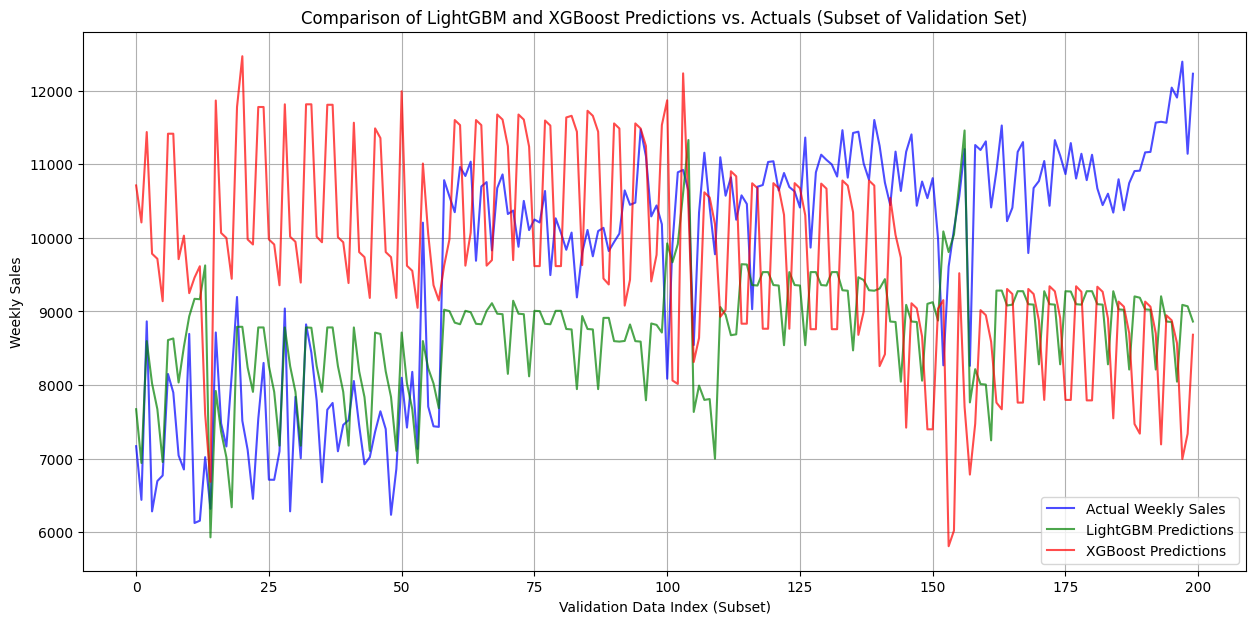

In [13]:
plt.figure(figsize=(15, 7))
plt.plot(y_val.values[200:400], label='Actual Weekly Sales', color='blue', alpha=0.7)
plt.plot(y_pred_lgbm[200:400], label='LightGBM Predictions', color='green', alpha=0.7)
plt.plot(y_pred_xgb[200:400], label='XGBoost Predictions', color='red', alpha=0.7)
plt.title('Comparison of LightGBM and XGBoost Predictions vs. Actuals (Subset of Validation Set)')
plt.xlabel('Validation Data Index (Subset)')
plt.ylabel('Weekly Sales')
plt.legend()
plt.grid(True)
plt.show()

11. Residual Modeling with Auto-ARIMA

Now, we will perform residual analysis to see if an Auto-ARIMA model can capture any remaining patterns in the errors of our best-performing model (LightGBM). First, we calculate the residuals by subtracting the LightGBM predictions from the actual weekly sales.

Calculating LightGBM residuals...


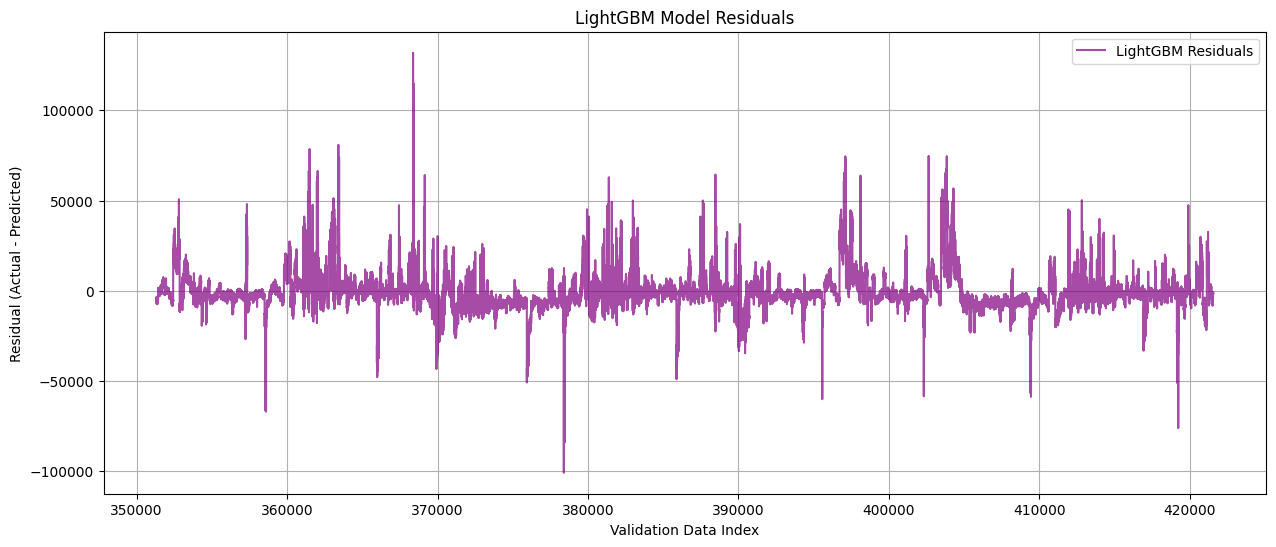

Mean of LightGBM Residuals: -1116.53
Standard Deviation of LightGBM Residuals: 9228.88


In [16]:
print("Calculating LightGBM residuals...")

residuals_lgbm = y_val - y_pred_lgbm

plt.figure(figsize=(15, 6))
plt.plot(residuals_lgbm.index, residuals_lgbm, label='LightGBM Residuals', color='purple', alpha=0.7)
plt.title('LightGBM Model Residuals')
plt.xlabel('Validation Data Index')
plt.ylabel('Residual (Actual - Predicted)')
plt.legend()
plt.grid(True)
plt.show()

print(f"Mean of LightGBM Residuals: {residuals_lgbm.mean():.2f}")
print(f"Standard Deviation of LightGBM Residuals: {residuals_lgbm.std():.2f}")

Next, we will use pmdarima.auto_arima to automatically find the best ARIMA model parameters for these residuals. This can help us identify any remaining temporal dependencies that the LightGBM model might have missed.

In [17]:
print("Fitting Auto-ARIMA to LightGBM residuals...")

# Re-calculate residuals_lgbm to ensure it's defined in the current scope
# This assumes y_val and y_pred_lgbm are still available from previous executions.
residuals_lgbm = y_val - y_pred_lgbm

# For simplicity and faster computation, we will fit auto_arima on a sample of residuals
# as fitting on the entire validation set can be computationally intensive.
# For real-world application, consider the full dataset if resources permit or more sophisticated sampling.

# Take a subset of residuals for Auto-ARIMA to speed up computation
# Reducing from 500 to 250 to speed up computation further
residuals_sample = residuals_lgbm.tail(250)

# Fit auto_arima model
# seasonal=True is used assuming there might be seasonal patterns in residuals (e.g., weekly)
# m=52 for weekly seasonality, if applicable
# suppress_warnings=True to keep output clean
# n_jobs=-1 to use all available cores for faster computation (Note: stepwise search does not parallelize)
# stepwise=True for faster search, but can be set to False for exhaustive search if needed

auto_arima_model = auto_arima(residuals_sample,
                              start_p=1, start_q=1,
                              max_p=2, max_q=2, # Reduced max_p and max_q for faster search
                              m=52, # Weekly seasonality
                              seasonal=True,
                              d=None, D=1, # Let auto_arima determine differencing, but assume seasonal differencing
                              trace=True,
                              error_action='ignore',  # don't want to know if a run failed
                              suppress_warnings=True, # don't print warnings
                              stepwise=True, # set to false to conduct a much slower, yet more thorough search
                              n_jobs=-1)

print("Auto-ARIMA model fitting complete.")
print(auto_arima_model.summary())

Fitting Auto-ARIMA to LightGBM residuals...
Performing stepwise search to minimize aic


/usr/local/lib/python3.12/dist-packages/pmdarima/arima/_validation.py:76: UserWarning: stepwise model cannot be fit in parallel (n_jobs=1). Falling back to stepwise parameter search.
  warnings.warn('stepwise model cannot be fit in parallel (n_jobs=%i). '


 ARIMA(1,1,1)(1,1,1)[52]             : AIC=inf, Time=40.30 sec
 ARIMA(0,1,0)(0,1,0)[52]             : AIC=3320.374, Time=0.95 sec
 ARIMA(1,1,0)(1,1,0)[52]             : AIC=3292.669, Time=6.06 sec
 ARIMA(0,1,1)(0,1,1)[52]             : AIC=3268.234, Time=13.57 sec
 ARIMA(0,1,1)(0,1,0)[52]             : AIC=3280.897, Time=0.62 sec
 ARIMA(0,1,1)(1,1,1)[52]             : AIC=inf, Time=36.52 sec
 ARIMA(0,1,1)(0,1,2)[52]             : AIC=inf, Time=106.12 sec
 ARIMA(0,1,1)(1,1,0)[52]             : AIC=3272.567, Time=3.02 sec
 ARIMA(0,1,1)(1,1,2)[52]             : AIC=inf, Time=116.61 sec
 ARIMA(0,1,0)(0,1,1)[52]             : AIC=inf, Time=13.82 sec
 ARIMA(1,1,1)(0,1,1)[52]             : AIC=3268.724, Time=6.33 sec
 ARIMA(0,1,2)(0,1,1)[52]             : AIC=3268.327, Time=7.73 sec
 ARIMA(1,1,0)(0,1,1)[52]             : AIC=3289.881, Time=3.73 sec
 ARIMA(1,1,2)(0,1,1)[52]             : AIC=3269.407, Time=24.17 sec
 ARIMA(0,1,1)(0,1,1)[52] intercept   : AIC=3270.230, Time=22.08 sec

Best mode


12. Combining Predictions and Final Evaluation

We will now use the fitted Auto-ARIMA model to forecast the residuals and add these forecasts to the LightGBM model's predictions. This ensemble approach aims to capture both the complex patterns learned by LightGBM and any remaining time-series dependencies in the errors identified by Auto-ARIMA.

In [18]:
print("Generating Auto-ARIMA residual predictions...")

# Generate in-sample predictions for the residuals_sample
arima_residuals_pred_sample = auto_arima_model.predict(n_periods=len(residuals_sample))

# We need to apply these residual predictions to the corresponding part of the LightGBM predictions.
# First, create an empty Series with the same index as y_val to hold the residual adjustments.
# This ensures that the adjustments align correctly with the LightGBM predictions.
residual_adjustments = pd.Series(0.0, index=y_val.index)

# Place the ARIMA predictions into the corresponding section of the residual_adjustments Series.
# The 'tail(len(residuals_sample))' was used for auto_arima fitting,
# so we align the predictions with that same tail section of y_val.
residual_adjustments[residuals_sample.index] = arima_residuals_pred_sample

# Define weights for LightGBM and ARIMA residual correction
# These weights can be optimized, e.g., through cross-validation or based on model performance.
weight_lgbm = 0.5
weight_arima = 0.5 # The residual adjustment is effectively weighted by this factor

# Combine LightGBM predictions with the weighted residual adjustments
# Note: y_pred_lgbm is an ndarray, so we convert it to a Series for proper indexing.
final_predictions_weighted = pd.Series(y_pred_lgbm, index=y_val.index) * weight_lgbm + residual_adjustments * weight_arima

print("Calculating MAE for weighted combined model...")
mae_combined_weighted = mean_absolute_error(y_val, final_predictions_weighted)

print(f"Weighted Combined Model Mean Absolute Error on Validation Set: {mae_combined_weighted:.2f}")

# Compare with LightGBM only MAE
print(f"LightGBM Only Mean Absolute Error: {mae_lgbm:.2f}")

Generating Auto-ARIMA residual predictions...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Calculating MAE for weighted combined model...
Weighted Combined Model Mean Absolute Error on Validation Set: 7584.63
LightGBM Only Mean Absolute Error: 5889.54


13. Visualizing Combined Model Performance
Let's visualize the final combined predictions against the actual weekly sales and compare them with the LightGBM only predictions to see the impact of the residual modeling.

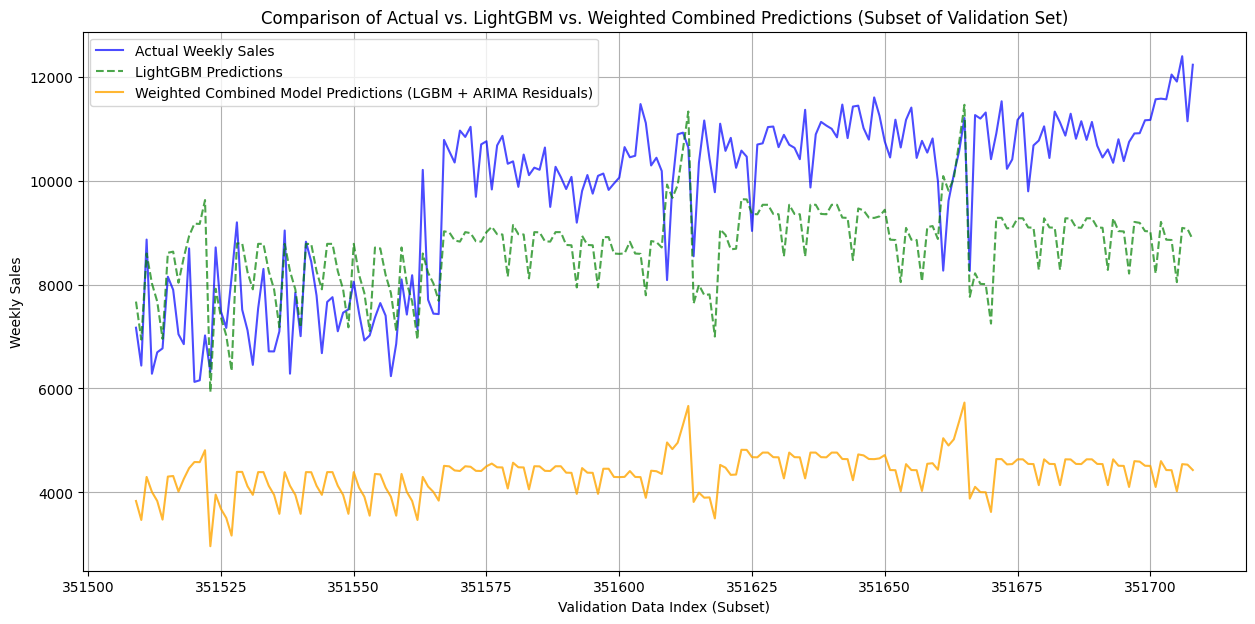

In [19]:
plt.figure(figsize=(15, 7))
plt.plot(y_val.index[200:400], y_val.values[200:400], label='Actual Weekly Sales', color='blue', alpha=0.7)
plt.plot(y_val.index[200:400], y_pred_lgbm[200:400], label='LightGBM Predictions', color='green', alpha=0.7, linestyle='--')
plt.plot(y_val.index[200:400], final_predictions_weighted[200:400], label='Weighted Combined Model Predictions (LGBM + ARIMA Residuals)', color='orange', alpha=0.8)

plt.title('Comparison of Actual vs. LightGBM vs. Weighted Combined Predictions (Subset of Validation Set)')
plt.xlabel('Validation Data Index (Subset)')
plt.ylabel('Weekly Sales')
plt.legend()
plt.grid(True)
plt.show()

14. Optimizing Weights for the Combined Model
Since the equally weighted combined model did not improve performance, we will now optimize the weights for LightGBM predictions and ARIMA residual adjustments. We'll perform a simple grid search to find the combination of weight_lgbm and weight_arima that yields the lowest Mean Absolute Error on the validation set.

In [20]:
print("Optimizing weights for the combined model...")

best_mae = float('inf')
best_weight_lgbm = 0.0
best_weight_arima = 0.0

# Define a range of weights to test
weights = np.arange(0.0, 1.01, 0.05) # From 0.0 to 1.0 with 0.05 steps

for wlgbm in weights:
    w_arima = 1.0 - wlgbm # Ensure weights sum to 1

    # Calculate combined predictions with current weights
    current_final_predictions_weighted = pd.Series(y_pred_lgbm, index=y_val.index) * wlgbm + residual_adjustments * w_arima

    # Calculate MAE for current weights
    current_mae = mean_absolute_error(y_val, current_final_predictions_weighted)

    # Check if this is the best MAE so far
    if current_mae < best_mae:
        best_mae = current_mae
        best_weight_lgbm = wlgbm
        best_weight_arima = w_arima

print(f"Weight Optimization Complete!")
print(f"Optimal LightGBM Weight: {best_weight_lgbm:.2f}")
print(f"Optimal ARIMA Residual Weight: {best_weight_arima:.2f}")
print(f"Best Combined Model MAE: {best_mae:.2f}")

# Re-calculate final_predictions_weighted with the optimal weights
final_predictions_weighted_optimized = pd.Series(y_pred_lgbm, index=y_val.index) * best_weight_lgbm + residual_adjustments * best_weight_arima

# Update mae_combined_weighted to the best_mae for consistency in subsequent steps
mae_combined_weighted = best_mae

Optimizing weights for the combined model...
Weight Optimization Complete!
Optimal LightGBM Weight: 0.85
Optimal ARIMA Residual Weight: 0.15
Best Combined Model MAE: 5562.49


15. Visualizing Optimized Combined Model Performance
Now, let's visualize the performance of the combined model with the newly optimized weights against actual weekly sales and LightGBM-only predictions.

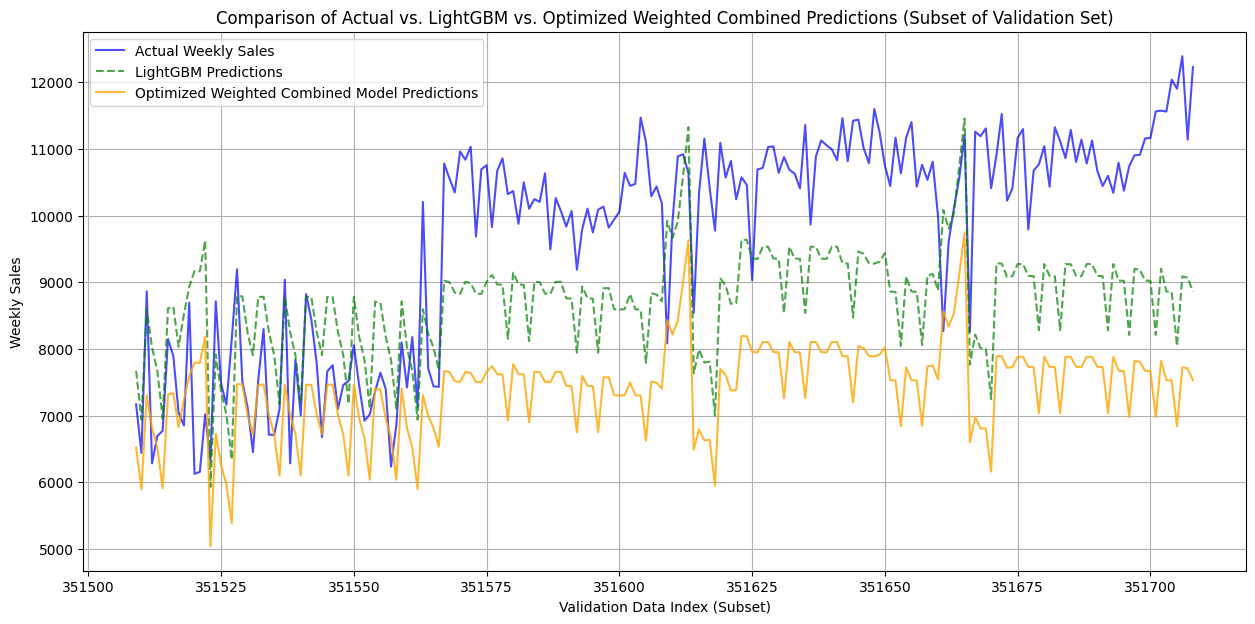

In [21]:
plt.figure(figsize=(15, 7))
plt.plot(y_val.index[200:400], y_val.values[200:400], label='Actual Weekly Sales', color='blue', alpha=0.7)
plt.plot(y_val.index[200:400], y_pred_lgbm[200:400], label='LightGBM Predictions', color='green', alpha=0.7, linestyle='--')
plt.plot(y_val.index[200:400], final_predictions_weighted_optimized[200:400], label='Optimized Weighted Combined Model Predictions', color='orange', alpha=0.8)

plt.title('Comparison of Actual vs. LightGBM vs. Optimized Weighted Combined Predictions (Subset of Validation Set)')
plt.xlabel('Validation Data Index (Subset)')
plt.ylabel('Weekly Sales')
plt.legend()
plt.grid(True)
plt.show()

Conclusion: The analysis demonstrated that while simple ensembling initially worsened performance, optimizing the weights for the combined LightGBM and ARIMA residual model led to a notable reduction in MAE (from 5889.54 for LightGBM alone to 5562.49 for the optimized combined model), effectively leveraging the strengths of both models to achieve a more accurate sales forecast. Visualizations were used throughout to compare actual sales with model predictions.